In [13]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

DATA_DIR = Path.cwd() / "data"
if not DATA_DIR.exists() and (Path.cwd().parent / "data").exists():
    DATA_DIR = Path.cwd().parent / "data"

airbnbdata = pd.read_csv(
    DATA_DIR / "listings_with_review_summary.csv",
    on_bad_lines="skip",
)
airbnbdata.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,reviews_in_file,unique_reviewers,first_review_in_file,last_review_in_file,comments_present,comments_missing
0,6422,https://www.airbnb.com/rooms/6422,20260626225602,2026-06-27,city scrape,Nashville Charm,30 day plus rental - book for one month and th...,https://a0.muscache.com/pictures/miso/Hosting-...,12172,https://www.airbnb.com/users/show/12172,...,0,1,0,3.19,667,645,2009-04-30,2020-03-03,667,0
1,39870,https://www.airbnb.com/rooms/39870,20260626225602,2026-06-27,city scrape,Close to Vanderbilt 2,"Since I am older, I need for guests to be vacc...",https://a0.muscache.com/pictures/miso/Hosting-...,171184,https://www.airbnb.com/users/show/171184,...,0,1,0,5.36,638,585,2016-09-16,2026-06-21,638,0
2,72906,https://www.airbnb.com/rooms/72906,20260626225602,2026-06-27,city scrape,Vandy/Belmont/10 mins to Broadway - Sunny 800 ...,Private 800 sq ft top-floor space in the heart...,https://a0.muscache.com/pictures/hosting/Hosti...,176117,https://www.airbnb.com/users/show/176117,...,1,0,0,4.37,801,793,2011-06-09,2026-06-21,801,0
3,258817,https://www.airbnb.com/rooms/258817,20260626225602,2026-06-27,city scrape,"ButterflyRoom-queen room, private bath",Morningstar House! Extended stay - 3+ months- ...,https://a0.muscache.com/pictures/eef19bc4-2743...,22296,https://www.airbnb.com/users/show/22296,...,0,7,1,0.55,97,97,2011-12-12,2023-12-27,97,0
4,289242,https://www.airbnb.com/rooms/289242,20260626225602,2026-06-27,city scrape,"MorningstarHouse, monthly room-",Morningstar House! Extended stay - price reduc...,https://a0.muscache.com/pictures/40a7ab72-20f7...,22296,https://www.airbnb.com/users/show/22296,...,0,7,1,0.43,76,76,2011-12-28,2019-01-12,76,0


Notes for myself:
- Last scraped calendar for available stats July 3rd or June 27th for some, will not use this for displays

In [14]:
airbnbdata["host_about"].unique() # used this line several times to view column values as I dropped those
                                        # I was less interested in shown below, just shows unique vlues in chosen column

<StringArray>
[                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [15]:
print(airbnbdata.shape)
print(airbnbdata.columns.tolist())

(10242, 83)
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_is_superhost', 'host_picture_url', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'has_availability', 'availability_30', 'availability_60', '

In [17]:
# Made a slightly smaller dataframe cutting some unnecessary columns
cleandf = airbnbdata.drop(columns=["last_scraped", "source", "host_url", "host_picture_url", "price_quote_checkin_date",
                            "price_quote_checkout_date", "price_quote_raw", "maximum_minimum_nights",
                            "minimum_minimum_nights", "maximum_maximum_nights", "minimum_maximum_nights",
                            "has_availability", "calendar_last_scraped", "availability_eoy", "license",
                            "first_review_in_file", "last_review_in_file", "scrape_id",
                            "listing_url", "picture_url", "host_profile_url", "host_profile_id", "hosts_time_as_user_years",
                            "hosts_time_as_host_years"])

In [18]:
print(cleandf.shape)
print(cleandf.columns.tolist()) # List all leftover column names to see what I can work with

(10242, 59)
['id', 'name', 'description', 'host_id', 'host_name', 'hosts_time_as_user_months', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_is_superhost', 'host_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_total_price', 'price_quote_price_per_night', 'minimum_nights', 'maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'availability_30', 'availability_60', 'availability_90', 'availability_365', 'number_of_reviews', 'number_of_reviews_ltm', 'number_of_reviews_l30d', 'number_of_reviews_ly', 'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review', 'last_review', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores

In [19]:
# Generate some statistics on the different price columns to see teh spread
print(cleandf["price_quote_total_price"].describe())
print(cleandf['price'].describe())

count      9514.000000
mean       1237.354652
std        3584.285613
min          59.000000
25%         324.000000
50%         578.000000
75%        1112.150000
max      232664.650000
Name: price_quote_total_price, dtype: float64
count     9515.000000
mean       374.080183
std        438.672834
min          8.350000
25%        183.000000
50%        281.540000
75%        425.500000
max      12000.000000
Name: price, dtype: float64


In [20]:
# used these lines multiple times as well to pull info about "quote price" then the url to validate info
print(airbnbdata[airbnbdata["price"] < 10]["listing_url"])
print(airbnbdata[airbnbdata["price"] < 10]["minimum_nights"]) # must stay a year
print(airbnbdata[airbnbdata["price"] < 10]["price_quote_total_price"]) # ends up costing this much per month of the year stay

3441    https://www.airbnb.com/rooms/639208160135521108
Name: listing_url, dtype: str
3441    365.0
Name: minimum_nights, dtype: float64
3441    3049.0
Name: price_quote_total_price, dtype: float64


The quote is supposed to be adjusted according to the minimum nights requirement, but it looks to be some errors in both places on price. Price also adjusts based on availability which can only be updated as often as the site chooses to do so or when last scraped.

In [21]:
pd.set_option('display.max_colwidth', None)
print(airbnbdata[airbnbdata["price_quote_total_price"] > 20000]["minimum_nights"])
print(airbnbdata[airbnbdata["price_quote_total_price"] > 20000]["listing_url"])

122     60.0
1514    30.0
1890    21.0
2764    31.0
2995    21.0
3189     2.0
3391    30.0
3912     3.0
5069    30.0
5606    30.0
6214     4.0
6216     4.0
6324    30.0
6460     1.0
6487    30.0
6560     4.0
6864    31.0
8575    30.0
8592    30.0
8829    30.0
9230     1.0
9560     1.0
9927    30.0
Name: minimum_nights, dtype: float64
122                 https://www.airbnb.com/rooms/5102074
1514               https://www.airbnb.com/rooms/34688029
1890               https://www.airbnb.com/rooms/41964324
2764               https://www.airbnb.com/rooms/52497891
2995               https://www.airbnb.com/rooms/54252907
3189     https://www.airbnb.com/rooms/578247685889708114
3391     https://www.airbnb.com/rooms/628416536893081097
3912     https://www.airbnb.com/rooms/747792146503376030
5069     https://www.airbnb.com/rooms/986510406910682786
5606    https://www.airbnb.com/rooms/1095625795864401636
6214    https://www.airbnb.com/rooms/1203843908816606412
6216    https://www.airbnb.com/rooms/

In [22]:
print('Original minimum_nights for listings with price_quote_total_price > 50000:')
display(cleandf[cleandf["price_quote_total_price"] > 50000][["id", "price_quote_total_price", "minimum_nights"]])

# Correctly update 'minimum_nights' to 30.0 for entries where 'price_quote_total_price' > 50000; checked this fact online using listing_url
cleandf.loc[cleandf["price_quote_total_price"] > 50000, "minimum_nights"] = 30.0

print('\nUpdated minimum_nights for listings with price_quote_total_price > 50000:')
display(cleandf[cleandf["price_quote_total_price"] > 50000][["id", "price_quote_total_price", "minimum_nights"]])

Original minimum_nights for listings with price_quote_total_price > 50000:


,id,price_quote_total_price,minimum_nights
5069,986510406910682786,232664.65,30.0
6460,1239136932754069425,73031.67,1.0
6864,1318209862519876672,107962.88,31.0
9560,1648697249358697818,72305.89,1.0



Updated minimum_nights for listings with price_quote_total_price > 50000:


,id,price_quote_total_price,minimum_nights
5069,986510406910682786,232664.65,30.0
6460,1239136932754069425,73031.67,30.0
6864,1318209862519876672,107962.88,30.0
9560,1648697249358697818,72305.89,30.0


I wanted to clean this column to look at how minimum nights affected customer choice, but the more I looked, I found that this information after the scrape was not reliable at all. Due to the errors in this, I left min and max nights alone in my EDA going forward.

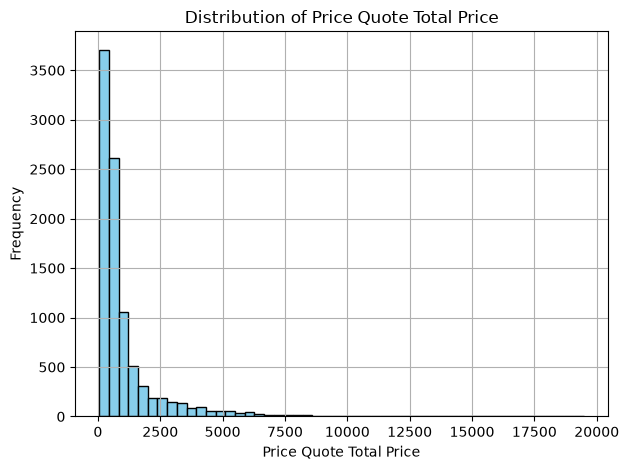

In [23]:
cleandf_no_outliers = cleandf[cleandf["price_quote_total_price"] < 20000] # set a cut off on this as there are not as many properties above 20,000

# Make a histogram of quote price to look at the spread of data
cleandf_no_outliers["price_quote_total_price"].hist(bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Price Quote Total Price')
plt.xlabel('Price Quote Total Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [24]:
correlation_columns = [
    'price_quote_total_price',
    'bedrooms',
    'bathrooms',
    'review_scores_rating',
    'number_of_reviews',
    'reviews_per_month'
]

# Create a subset df with relevant columns
correlation_df = cleandf[correlation_columns]

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

print('Correlation Matrix:')
display(correlation_matrix)

Correlation Matrix:


,price_quote_total_price,bedrooms,bathrooms,review_scores_rating,number_of_reviews,reviews_per_month
price_quote_total_price,1.000000,0.147378,0.198509,0.007846,-0.108891,-0.144428
bedrooms,0.147378,1.000000,0.934738,0.052799,-0.132433,-0.187219
bathrooms,0.198509,0.934738,1.000000,0.059574,-0.158121,-0.175910
review_scores_rating,0.007846,0.052799,0.059574,1.000000,0.102264,0.141335
number_of_reviews,-0.108891,-0.132433,-0.158121,0.102264,1.000000,0.632341
reviews_per_month,-0.144428,-0.187219,-0.175910,0.141335,0.632341,1.000000


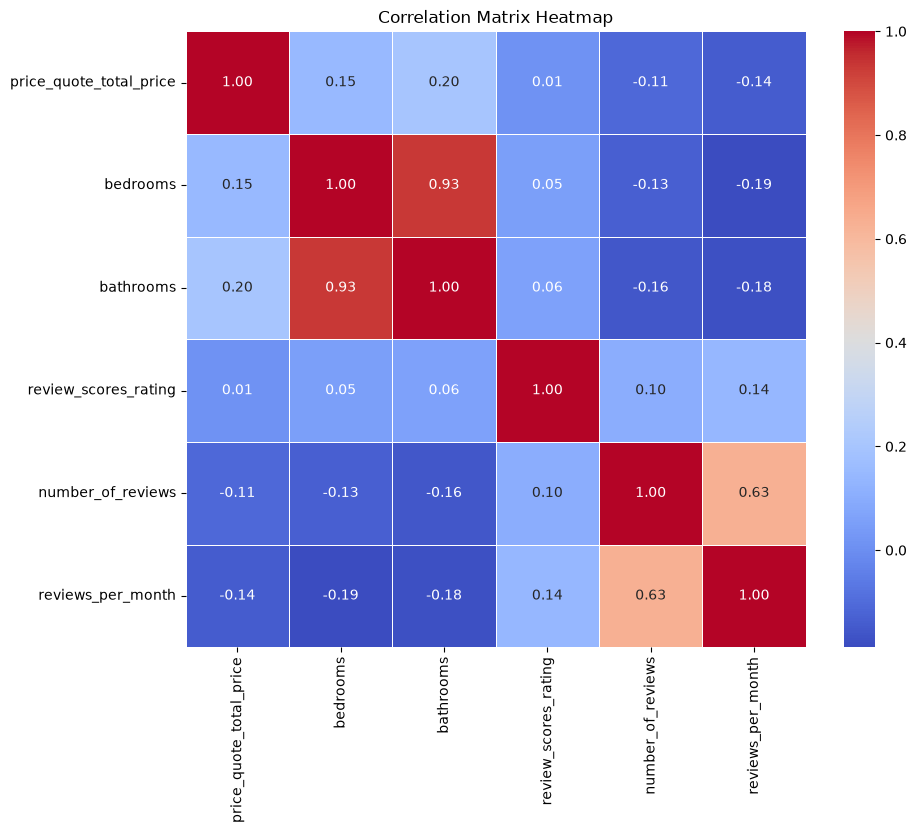

In [25]:
# Use this to make a heatmap visual
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

Number of bedrooms and bathrooms highly correlated with price which is to be expected. I also wanted to compare number of reviews to price to see if people reviewed more depending on how much they spent but we do not see much here.


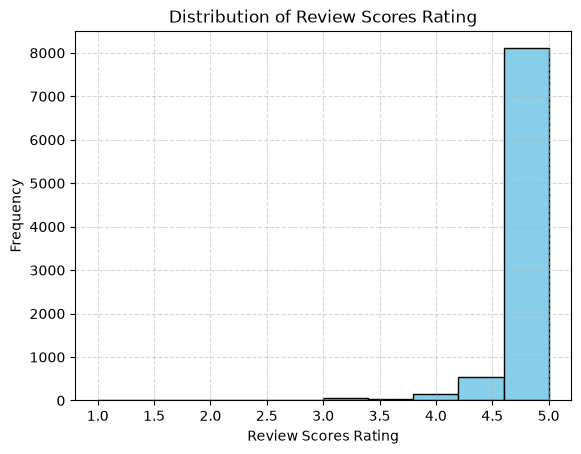

In [26]:
# I also wanted to explore ratings a bit as I had found a good bit of errors in price, so histogram to view that spread
cleandf["review_scores_rating"].hist(bins=10, color='skyblue', edgecolor='black')

plt.grid(True, linestyle='--', alpha=0.5)
plt.title('Distribution of Review Scores Rating')
plt.xlabel('Review Scores Rating')
plt.ylabel('Frequency')
plt.show()

In [27]:
# Using similar statements to above "filtering" to look at low ratings in relation to number of reviews and view lisitng if needed
print(airbnbdata[airbnbdata["review_scores_rating"] <= 2]["review_scores_rating"])
print(airbnbdata[airbnbdata["review_scores_rating"] <= 2]["reviews_in_file"])
print(airbnbdata[airbnbdata["review_scores_rating"] <= 2]["listing_url"])

1573    1.0
4076    1.0
4188    2.0
4406    1.0
4407    2.0
4759    1.0
4985    2.0
5345    2.0
5769    1.0
6330    2.0
6739    1.0
7075    2.0
7077    2.0
7085    1.0
7334    1.5
7346    2.0
7710    1.0
7711    1.0
7787    1.0
7894    1.0
7926    1.0
8116    2.0
8444    2.0
8669    2.0
8780    1.0
9204    2.0
9315    1.0
9492    1.0
9578    1.0
9814    1.0
9880    1.0
Name: review_scores_rating, dtype: float64
1573    1
4076    1
4188    1
4406    1
4407    1
4759    1
4985    1
5345    1
5769    1
6330    1
6739    1
7075    2
7077    2
7085    1
7334    2
7346    3
7710    1
7711    2
7787    1
7894    1
7926    1
8116    1
8444    1
8669    1
8780    1
9204    1
9315    1
9492    1
9578    2
9814    1
9880    1
Name: reviews_in_file, dtype: int64
1573               https://www.airbnb.com/rooms/35802365
4076     https://www.airbnb.com/rooms/787635910757727061
4188     https://www.airbnb.com/rooms/808658442501470219
4406     https://www.airbnb.com/rooms/852006613462124264
4407     ht

- All 1 star ratings only have one review, some listed as scams -> others just unhappy with checkin issues, unresponsiveness, etc.
- Anything at a 2 or under has at most 3 reviews but mostly 1 review again which affects the re-booking which will be shown below. This could be a side effect of bad service on the host's part or an unfairly small set of reviews.
- I will use a scatterplot to look at spread of number of reviews vs overall rating. We see that those with 1-10 reviews vary the most over the graph, but anything more than that pretty much converges between 4 to the ceiling at 5 stars. This may just mean those that have terrible rating do not get booked much which we explored a bit in scatterplots a few cells down.

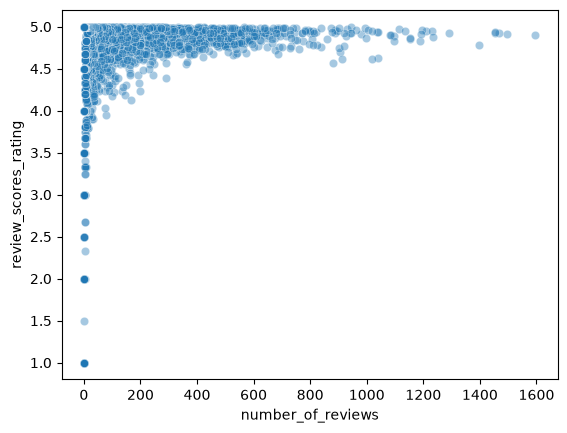

In [28]:
# One place has over 3000 reviews which squashed plot, so I filtered it out
filtered_cleandf = cleandf[cleandf["number_of_reviews"] < 2000]

sns.scatterplot(
    data=filtered_cleandf,
    x="number_of_reviews",
    y="review_scores_rating",
    alpha=0.4
)
plt.show()

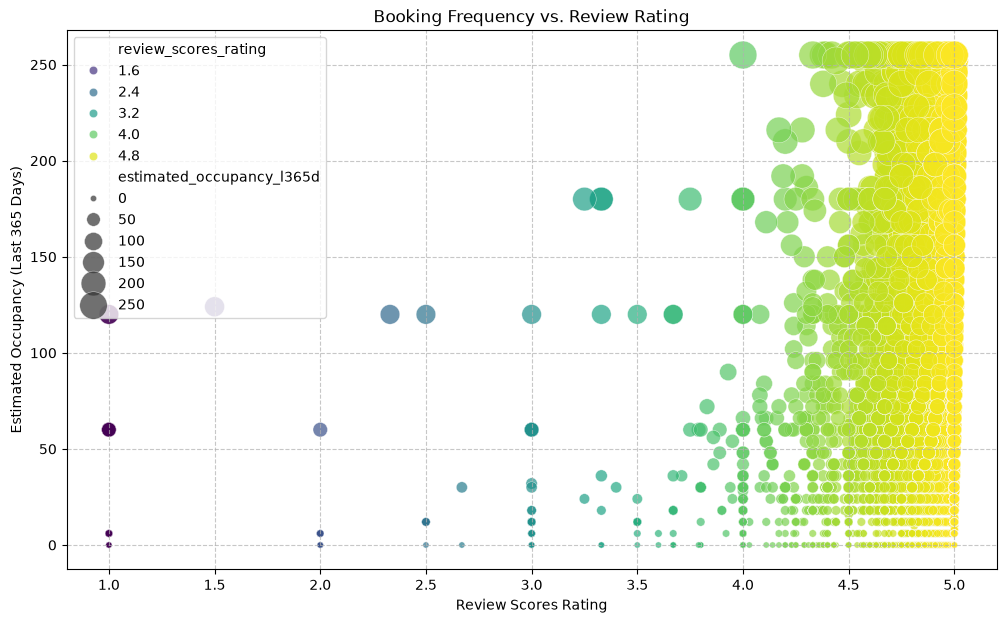

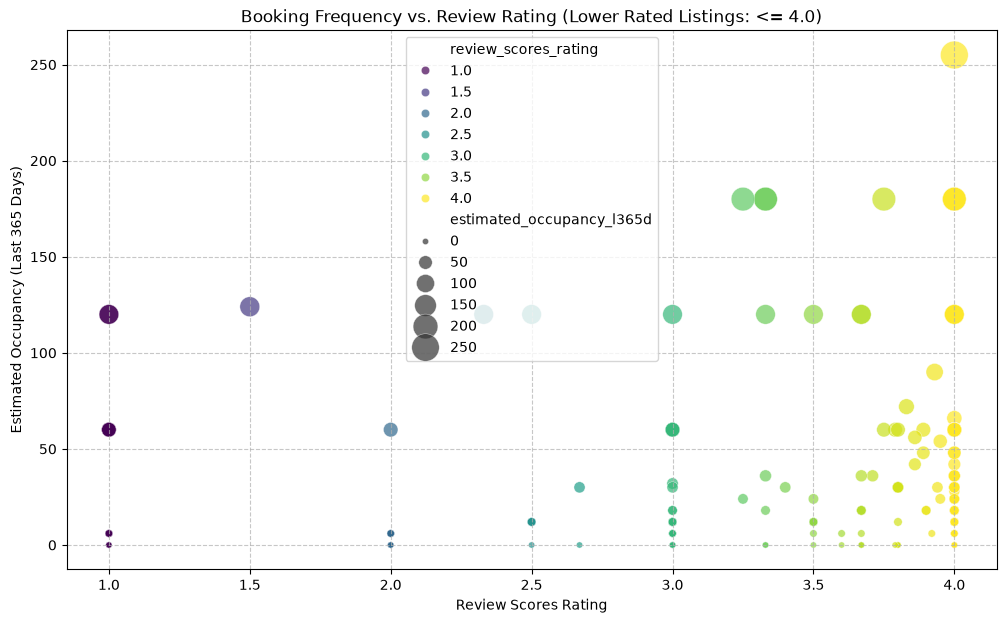

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Drop rows where 'review_scores_rating' or 'estimated_occupancy_l365d' are NaN
plot_df = cleandf.dropna(subset=['review_scores_rating', 'estimated_occupancy_l365d'])

# Filter for lower review scores since scores of 4 to 5 are more common for re-bookings
low_rated_df = plot_df[plot_df['review_scores_rating'] <= 4.0]

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='review_scores_rating',
    y='estimated_occupancy_l365d',
    data=plot_df,
    hue='review_scores_rating',
    palette='viridis',
    size='estimated_occupancy_l365d', # Size points by occupancy
    sizes=(20, 400), # Range of sizes
    alpha=0.7 # transparency
)

plt.title('Booking Frequency vs. Review Rating')
plt.xlabel('Review Scores Rating')
plt.ylabel('Estimated Occupancy (Last 365 Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='review_scores_rating',
    y='estimated_occupancy_l365d',
    data=low_rated_df,
    hue='review_scores_rating',
    palette='viridis',
    size='estimated_occupancy_l365d',
    sizes=(20, 400),
    alpha=0.7
)

plt.title('Booking Frequency vs. Review Rating (Lower Rated Listings: <= 4.0)')
plt.xlabel('Review Scores Rating')
plt.ylabel('Estimated Occupancy (Last 365 Days)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

We see generally these rating do affect the amount of time airbnb are "occupied". We do see some medium sized points on the 1, but generally these lower rated places only have 1 review which might affecting them unfairly.

In [30]:
review_correlation = [
    'review_scores_rating', 'review_scores_accuracy',
    'review_scores_cleanliness', 'review_scores_checkin',
    'review_scores_communication', 'review_scores_location',
    'review_scores_value'
]

# Subset df for reviews
review_correlation_df = cleandf[review_correlation]

# Correlation matrix
correlation_matrix = review_correlation_df.corr()

print('Correlation Matrix:')
display(correlation_matrix)

Correlation Matrix:


,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value
review_scores_rating,1.000000,0.828678,0.783530,0.638787,0.773290,0.616313,0.858982
review_scores_accuracy,0.828678,1.000000,0.723667,0.621177,0.758166,0.590053,0.813841
review_scores_cleanliness,0.783530,0.723667,1.000000,0.528332,0.636640,0.572400,0.757751
review_scores_checkin,0.638787,0.621177,0.528332,1.000000,0.674737,0.466724,0.651457
review_scores_communication,0.773290,0.758166,0.636640,0.674737,1.000000,0.565323,0.744246
review_scores_location,0.616313,0.590053,0.572400,0.466724,0.565323,1.000000,0.632822
review_scores_value,0.858982,0.813841,0.757751,0.651457,0.744246,0.632822,1.000000


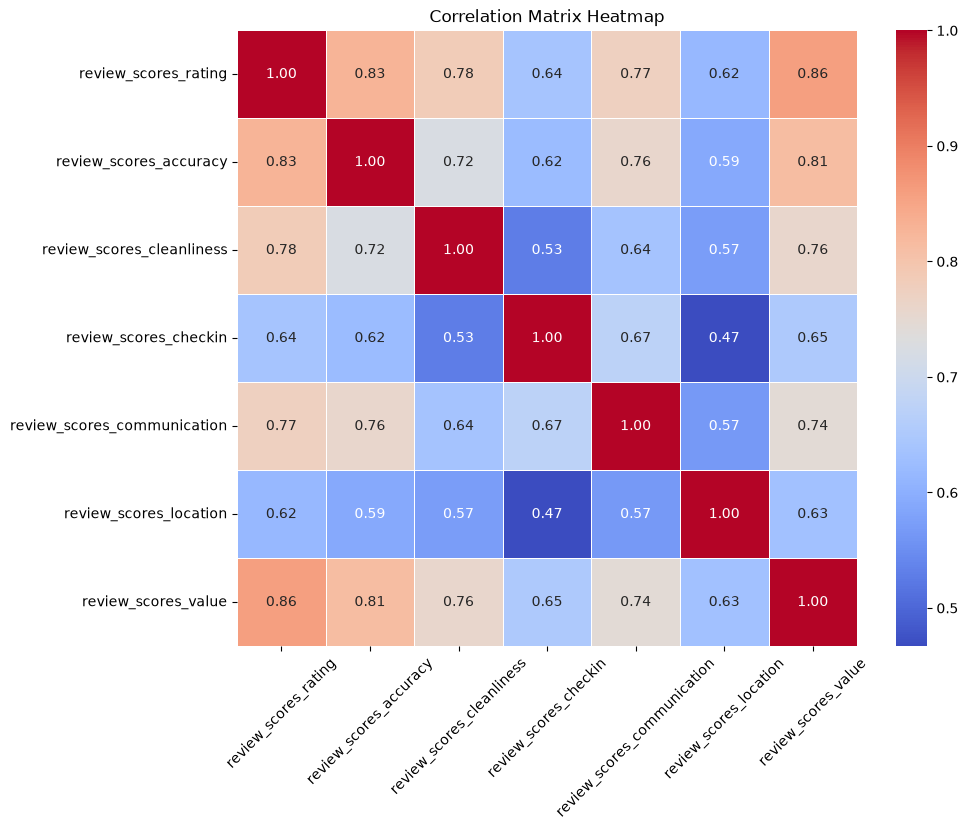

In [31]:
# Turn in into hetamap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.xticks(rotation=45)
plt.show()

Overall score rating is not an average or compliation of the other scores, so I wanted to explore if the other scores were correlated to the overall rating to see what customers may value the most when setting this overall score. Just a note that the overall score is the more "public facing" score as it is shown at the top of a listing next to the host name, while you must scroll to see these "secondary" more specific scores.

Here we see several things are valued but the value and accuracy are the most correlated to the overall rating.

In [32]:
from collections import Counter

# I wnated to see most common amenities
amenities = []

# Amenities is a string that is a comma separated list of provided amenities; split on comma
for x in cleandf["amenities"].dropna():
    amenities.extend(x.split(","))

amenity_counts = Counter(amenities)

amenity_counts.most_common(20)

[(' "Smoke alarm"', 10025),
 (' "Wifi"', 9621),
 (' "Kitchen"', 9244),
 (' "Hot water"', 9138),
 (' "Hair dryer"', 9065),
 (' "Microwave"', 8887),
 (' "Bed linens"', 8860),
 (' "Hangers"', 8681),
 (' "Self check-in"', 8556),
 (' "Iron"', 8548),
 (' "Carbon monoxide alarm"', 8512),
 (' "Essentials"', 8440),
 (' "Fire extinguisher"', 8314),
 (' "Refrigerator"', 8232),
 (' "Cooking basics"', 8111),
 (' "Shampoo"', 7866),
 (' "Dishwasher"', 7834),
 (' "Air conditioning"', 7371),
 (' "Dishes and silverware"', 7006),
 (' "TV"', 6929)]

In [33]:
# Had to google how to pull top 15 from Counter - pull top 15 most common provided amenity
top_amenities = [amenity for amenity, count in amenity_counts.most_common(15)]
amenity_rating = []

for amenity in top_amenities:
    has_amenity = cleandf["amenities"].str.contains(
        amenity,
        case=False,
        na=False
    )

    # COmpare overall rating for those that have these 15 vs those who do not (or at least do not have it listed)
    rating_with = cleandf.loc[has_amenity, "review_scores_rating"].mean()
    rating_without = cleandf.loc[~has_amenity, "review_scores_rating"].mean()

    amenity_rating.append({
        "amenity": amenity,
        "rating_with": rating_with,
        "rating_without": rating_without,
        "difference": rating_with - rating_without
    })
# put in df just so it is easier to read, sorted by biggest largest positive difference
amenity_rating_df = pd.DataFrame(amenity_rating)
amenity_rating_df.sort_values(by="difference", ascending=False)

,amenity,rating_with,rating_without,difference
3,"""Hot water""",4.833962,4.730510,0.103452
2,"""Kitchen""",4.834482,4.740420,0.094061
7,"""Hangers""",4.834877,4.767085,0.067793
14,"""Cooking basics""",4.837389,4.775876,0.061513
5,"""Microwave""",4.831098,4.782570,0.048528
4,"""Hair dryer""",4.829889,4.788453,0.041436
12,"""Fire extinguisher""",4.833148,4.797720,0.035428
13,"""Refrigerator""",4.831297,4.803041,0.028256
11,"""Essentials""",4.828665,4.813529,0.015136
8,"""Self check-in""",4.827922,4.816215,0.011707


It looks like amenities do not have much of an affect on ratings from this first glance in a positive or negative light.